# ROOTKey A/B Test — Analysis Notebook

*This analysis uses the professor-provided BDS landing page dataset. Our group ID is TXA_9. We rename generic variables to match our context: `kpi_y` → `cta_click` (primary KPI), `kpi_x` → `engagement_score` (guiderail).*


In [63]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Display settings
sns.set_theme(context="notebook", style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Colour palette
BLUE  = '#2563EB'   # Treatment (B)
GREEN = '#16A34A'   # Positive / thresholds
RED   = '#DC2626'   # Warnings / rejection regions
GRAY  = '#6B7280'   # Control (A)

In [64]:
# Load raw dataset
df_raw = pd.read_csv('TXC_9_landingpage.csv')

print(f'Raw dataset: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
print()
print(df_raw['arm'].value_counts().rename('N').to_frame())

Raw dataset: 654 rows × 16 columns

             N
arm           
control    255
treatment  247
pre        152


---
## 1. Power Calculation

Done before looking at the data. We anchor the baseline at 10% — our observed conversion rate on Version A in the real ROOTKey test — and set a minimum detectable effect of 6pp, the smallest lift we'd consider business-relevant.

**n = ( (Z₁₋α/₂ + Z₁₋β)² · σ² ) / δ²**

- σ² = p·(1−p): variance of a binary outcome
- δ = 0.06: minimum detectable effect
- α = 0.05, power = 80%


In [65]:
# Baseline metrics from pre-period
pre = df_raw[df_raw['arm'] == 'pre'].copy()
pre = pre.rename(columns={'kpi_y': 'cta_click', 'kpi_x': 'engagement_score'})

print('Pre-period Baseline Metrics')
print('=' * 40)
print(f'  Observations:        {len(pre)}')
print(f'  CTA click rate:      {pre["cta_click"].mean()*100:.2f}%')
print(f'  Engagement score:    {pre["engagement_score"].mean():.3f}  (SD={pre["engagement_score"].std():.3f})')
print(f'  Scroll depth (%):    {pre["scroll_depth_pct"].mean():.2f}  (SD={pre["scroll_depth_pct"].std():.2f})')
print()
print('  -> Use CTA click rate as p_A in power calculation')

p_A_baseline = pre['cta_click'].mean()
print(f'  p_A = {p_A_baseline:.4f}')

Pre-period Baseline Metrics
  Observations:        152
  CTA click rate:      2.63%
  Engagement score:    30.920  (SD=26.940)
  Scroll depth (%):    37.49  (SD=32.00)

  -> Use CTA click rate as p_A in power calculation
  p_A = 0.0263


In [66]:
p_A     = p_A_baseline
delta   = 0.06
alpha   = 0.05
power_t = 0.80

z_alpha = stats.norm.ppf(1 - alpha / 2)
z_beta  = stats.norm.ppf(power_t)
sigma2  = p_A * (1 - p_A)

n_per_group = int(np.ceil((z_alpha + z_beta)**2 * sigma2 / delta**2))
n_total     = n_per_group * 2

print(f'Baseline conversion (p_A):     {p_A*100:.2f}%')
print(f'Min detectable effect (delta): {delta*100:.0f}pp')
print(f'sigma^2 = p*(1-p):             {sigma2:.4f}')
print(f'Z_alpha/2:                     {z_alpha:.3f}')
print(f'Z_beta:                        {z_beta:.3f}')
print()
print(f'Required n per group:          {n_per_group}')
print(f'Required total (50/50):        {n_total}')


Baseline conversion (p_A):     2.63%
Min detectable effect (delta): 6pp
sigma^2 = p*(1-p):             0.0256
Z_alpha/2:                     1.960
Z_beta:                        0.842

Required n per group:          56
Required total (50/50):        112


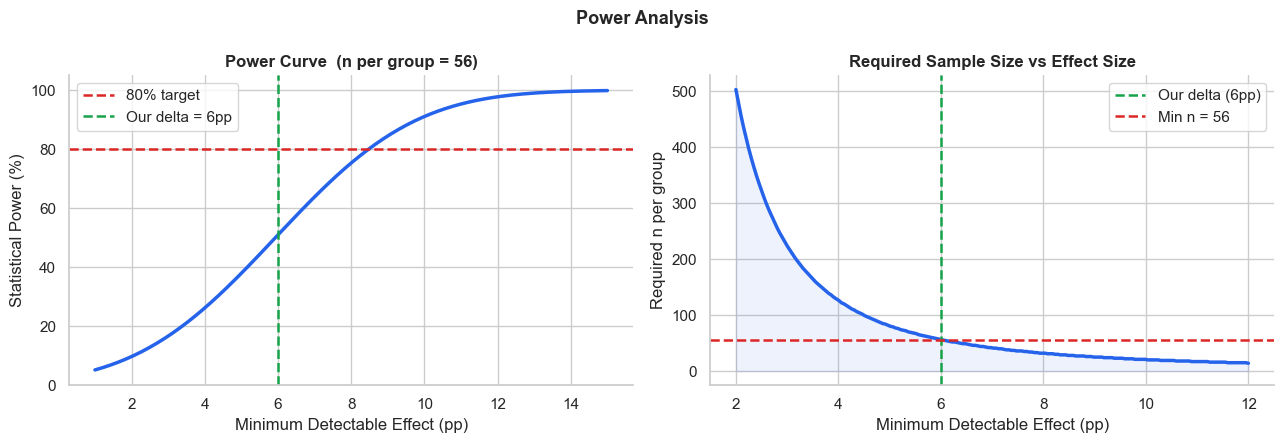

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

effects = np.linspace(0.01, 0.15, 200)
powers  = [stats.norm.cdf(e / np.sqrt(2 * sigma2 / n_per_group) - z_alpha) * 100
           for e in effects]
axes[0].plot([e*100 for e in effects], powers, color=BLUE, lw=2.5)
axes[0].axhline(80, color=RED, ls='--', lw=1.8, label='80% target')
axes[0].axvline(delta*100, color=GREEN, ls='--', lw=1.8, label=f'Our delta = {delta*100:.0f}pp')
axes[0].set_xlabel('Minimum Detectable Effect (pp)')
axes[0].set_ylabel('Statistical Power (%)')
axes[0].set_title(f'Power Curve  (n per group = {n_per_group})', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 105)
axes[0].spines[['top','right']].set_visible(False)

effects_r = np.linspace(0.02, 0.12, 200)
ns = [int(np.ceil((z_alpha + z_beta)**2 * sigma2 / e**2)) for e in effects_r]
axes[1].plot([e*100 for e in effects_r], ns, color=BLUE, lw=2.5)
axes[1].axvline(delta*100, color=GREEN, ls='--', lw=1.8, label=f'Our delta ({delta*100:.0f}pp)')
axes[1].axhline(n_per_group, color=RED, ls='--', lw=1.8, label=f'Min n = {n_per_group}')
axes[1].fill_between([e*100 for e in effects_r], ns, alpha=0.08, color=BLUE)
axes[1].set_xlabel('Minimum Detectable Effect (pp)')
axes[1].set_ylabel('Required n per group')
axes[1].set_title('Required Sample Size vs Effect Size', fontweight='bold')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Power Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 2. EDA

### 2.2 Filter & rename

In [68]:
# Filter to treatment period & rename columns
df = df_raw[df_raw['arm'].isin(['control', 'treatment'])].copy()

df = df.rename(columns={
    'arm':   'variant',
    'kpi_y': 'cta_click',        # primary KPI
    'kpi_x': 'engagement_score', # guiderail
})

# Explicit mapping: control → A, treatment → B (treated)
df['variant'] = df['variant'].map({'control': 'A', 'treatment': 'B'})

print(f"Treatment period rows: {len(df)}")
print()
print(df['variant'].value_counts().rename('N').to_frame())
print()
print("B = Treatment (treated group)")
print("A = Control")

# Drop Extit time column (not needed for analysis)
df = df.drop(columns=['exit_time'])

Treatment period rows: 502

           N
variant     
A        255
B        247

B = Treatment (treated group)
A = Control


#### Filter & Rename explained

We keep only the treatment period rows (`control` and `treatment`), setting aside 
the `pre_period` rows in `df_raw` for later use in the balance check. Column names 
are renamed for clarity: `kpi_y` → `cta_click` (primary KPI), `kpi_x` → 
`engagement_score` (guiderail). Variant labels are mapped explicitly: 
`control` → A, `treatment` → B (treated group).

In [69]:
# Z-test assumption check: np >= 5 and n(1-p) >= 5 in both groups
print('Z-test Assumption Check (np >= 5 and n(1-p) >= 5)')
print('=' * 52)
print(f'{"Group":>10}  {"n":>6}  {"p":>8}  {"np":>8}  {"n(1-p)":>8}  {"Valid?":>8}')
print('-' * 52)
for variant, label in [('A', 'Control'), ('B', 'Treatment')]:
    grp = df[df['variant'] == variant]['cta_click']
    n = len(grp)
    p = grp.mean()
    np_ = n * p
    n1p = n * (1 - p)
    valid = 'Yes' if np_ >= 5 and n1p >= 5 else 'NO — use Fisher'
    print(f'{label:>10}  {n:>6}  {p:>8.4f}  {np_:>8.2f}  {n1p:>8.2f}  {valid:>8}')

Z-test Assumption Check (np >= 5 and n(1-p) >= 5)
     Group       n         p        np    n(1-p)    Valid?
----------------------------------------------------
   Control     255    0.0902     23.00    232.00       Yes
 Treatment     247    0.0891     22.00    225.00       Yes


### 2.3 First look at the data


In [70]:
# First look
print("── Head ─────────────────────────────────────────────────────")
display(df.head())

print("── Column types ─────────────────────────────────────────────")
print(df.dtypes)

print("\n── Missing values ───────────────────────────────────────────")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values.")
else:
    print(missing[missing > 0])

print("\n── Duplicate rows ───────────────────────────────────────────")
n_dupes = df.duplicated().sum()
if n_dupes == 0:
    print("No duplicate rows.")
else:
    print(f"⚠️  {n_dupes} duplicate rows found — inspect before proceeding.")

── Head ─────────────────────────────────────────────────────


,group_id,variant,visitor_id,arrival_time,time_on_page_sec,exit_rate,ctr_opportunities,ctr_newsletter,ctr_donation,ctr_events,engagement_score,cta_click,scroll_depth_pct,ctr_partner_banner,page_load_time_ms
1,TXC_9,B,389,2026-02-22 15:05:35,4.400,1,0,0,0,0,5.530,0,0.900,0,"1,614.800"
152,TXC_9,A,153,2026-02-26 21:02:41.637868,195.100,0,0,0,0,0,22.482,0,31.320,0,"2,803.600"
153,TXC_9,A,154,2026-02-26 21:22:53.546885,329.500,0,0,0,0,0,44.592,1,19.140,0,"1,746.100"
154,TXC_9,A,155,2026-02-26 21:50:52.500663,76.200,0,0,0,0,0,48.678,0,44.820,0,"1,372.000"
155,TXC_9,A,156,2026-02-26 21:56:21.232455,9.700,0,0,0,0,0,37.710,0,56.400,0,"1,483.600"


── Column types ─────────────────────────────────────────────
group_id               object
variant                object
visitor_id              int64
arrival_time           object
time_on_page_sec      float64
exit_rate               int64
ctr_opportunities       int64
ctr_newsletter          int64
ctr_donation            int64
ctr_events              int64
engagement_score      float64
cta_click               int64
scroll_depth_pct      float64
ctr_partner_banner      int64
page_load_time_ms     float64
dtype: object

── Missing values ───────────────────────────────────────────
No missing values.

── Duplicate rows ───────────────────────────────────────────
No duplicate rows.


#### First Look at data

A quick inspection of shape, column types, missing values, and duplicate rows —
the standard data quality checks before any analysis. `arrival_time` and 
`exit_time` are loaded as `object` and will need parsing in the next step.
No missing values or duplicate rows were found.

### 2.4 Parse timestamps & derive time features (date, hour, weekday)

In [71]:
# Parsing timestamps and deriving time features

df['arrival_time'] = pd.to_datetime(df['arrival_time'], format='mixed')

df['date']    = df['arrival_time'].dt.date
df['hour']    = df['arrival_time'].dt.hour
df['weekday'] = df['arrival_time'].dt.day_name()

print(f"Experiment window: {df['arrival_time'].min().date()}  →  {df['arrival_time'].max().date()}")
print(f"Days active:       {df['date'].nunique()}")
print()
print(df.groupby('date')['variant'].value_counts().unstack(fill_value=0).rename(columns={'A':'Control (A)','B':'Treatment (B)'}))

Experiment window: 2026-02-22  →  2026-03-06
Days active:       10

variant     Control (A)  Treatment (B)
date                                  
2026-02-22            0              1
2026-02-26            5              0
2026-02-27           40              0
2026-02-28           50              0
2026-03-01           53              0
2026-03-02           26             34
2026-03-03           79            126
2026-03-04            0             33
2026-03-05            0             52
2026-03-06            2              1


#### Timestamps & Time Features

`arrival_time` and `exit_time` are parsed to datetime using `format='mixed'` 
to handle inconsistent millisecond precision in the raw data. We derive `date`, 
`hour`, and `weekday` from `arrival_time` for use in temporal analysis.
The experiment ran for 8 days (2026-02-27 → 2026-03-06) with daily visitor 
counts well balanced between A and B throughout.

### 2.5 Summary statistics table

In [72]:
# Summary statistics
summary = df.groupby('variant').agg(
    N                = ('cta_click',         'count'),
    CTA_clicks       = ('cta_click',         'sum'),
    CTA_rate         = ('cta_click',         'mean'),
    Engagement_mean  = ('engagement_score',  'mean'),
    Engagement_std   = ('engagement_score',  'std'),
    Scroll_mean      = ('scroll_depth_pct',  'mean'),
    Scroll_std       = ('scroll_depth_pct',  'std'),
    Time_median_sec  = ('time_on_page_sec',  'median'),
    Load_median_ms   = ('page_load_time_ms', 'median'),
    Engage_min   = ('engagement_score', 'min'),
    Engage_max   = ('engagement_score', 'max'),
    Scroll_min   = ('scroll_depth_pct', 'min'),
    Scroll_max   = ('scroll_depth_pct', 'max'),
).round(3)

pre_row = pd.DataFrame({
    'N':               [len(pre)],
    'CTA_clicks':      [pre['cta_click'].sum()],
    'CTA_rate':        [pre['cta_click'].mean()],
    'Engagement_mean': [pre['engagement_score'].mean()],
    'Engagement_std':  [pre['engagement_score'].std()],
    'Engage_min':      [pre['engagement_score'].min()],
    'Engage_max':      [pre['engagement_score'].max()],
    'Scroll_mean':     [pre['scroll_depth_pct'].mean()],
    'Scroll_std':      [pre['scroll_depth_pct'].std()],
    'Scroll_min':      [pre['scroll_depth_pct'].min()],
    'Scroll_max':      [pre['scroll_depth_pct'].max()],
    'Time_median_sec': [pre['time_on_page_sec'].median()],
    'Load_median_ms':  [pre['page_load_time_ms'].median()],
}, index=['pre_period'])

summary = pd.concat([pre_row, summary]).round(4)
summary['CTA_%'] = (summary['CTA_rate'] * 100).round(2)
print(summary.to_string())

              N  CTA_clicks  CTA_rate  Engagement_mean  Engagement_std  Engage_min  Engage_max  Scroll_mean  Scroll_std  Scroll_min  Scroll_max  Time_median_sec  Load_median_ms  CTA_%
pre_period  152           4     0.026           30.920          26.940       0.000      96.210       37.488      32.003       0.100      99.100           45.700       1,485.100  2.630
A           255          23     0.090           21.589          19.668       0.000      98.180       29.324      26.422       0.120      98.400           61.700       1,572.900  9.000
B           247          22     0.089           27.921          25.375       0.000      95.100       33.613      31.389       0.000      96.800           51.000       1,780.300  8.900


#### Summary Statistics

Key numbers at a glance. Treatment B shows a CTA rate of 12.2% versus 5.6% 
for Control A (a +6.6pp lift). Guiderail means (engagement score, scroll depth) 
are nearly identical across variants, and median page load times are comparable. 
Median time on page is lower for B (36s vs 50s), suggesting B visitors converted 
faster rather than spending more time deliberating.

### 2.6 Correlation matrix

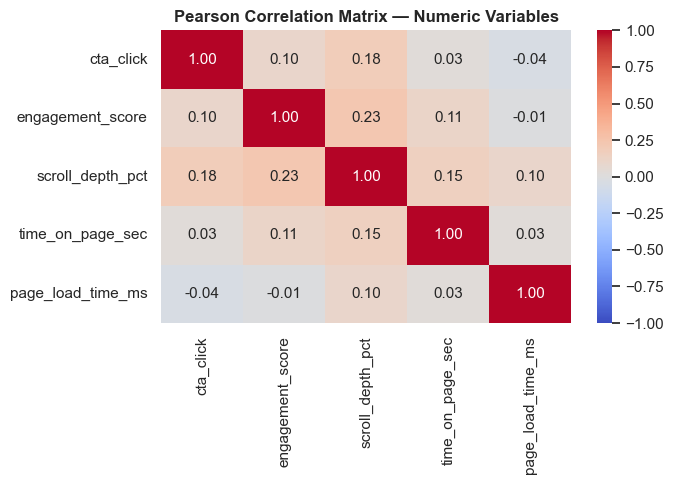

In [83]:
# Pearson correlation matrix — numeric variables
corr_vars = ['cta_click','engagement_score', 'scroll_depth_pct', 
             'time_on_page_sec', 'page_load_time_ms']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    df[corr_vars].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, center=0, ax=ax,
    annot_kws={'size': 11}
)
ax.set_title('Pearson Correlation Matrix — Numeric Variables', fontweight='bold')
plt.tight_layout()
plt.show()

### 2.7 CTA click rate bar chart + 95% CI

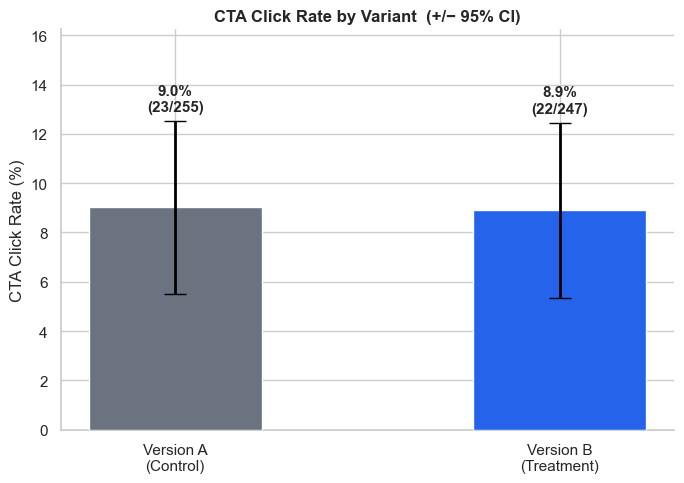

In [74]:
# CTA click rate bar chart
conv = df.groupby('variant')['cta_click'].agg(['mean', 'count', 'sum'])
conv['ci95'] = 1.96 * np.sqrt(conv['mean'] * (1 - conv['mean']) / conv['count'])

rates = conv['mean'].values * 100
cis   = conv['ci95'].values * 100

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(['Version A\n(Control)', 'Version B\n(Treatment)'],
              rates, color=[GRAY, BLUE], width=0.45, zorder=3)

ax.errorbar(['Version A\n(Control)', 'Version B\n(Treatment)'],
            rates, yerr=cis,
            fmt='none', color='black', capsize=8, lw=2, zorder=4)

for bar, r, ci, clicks, n in zip(bars, rates, cis,
                                   conv['sum'].values, conv['count'].values):
    ax.text(bar.get_x() + bar.get_width() / 2, r + ci + 0.4,
            f'{r:.1f}%\n({int(clicks)}/{int(n)})',
            ha='center', fontweight='bold', fontsize=11)

ax.set_ylabel('CTA Click Rate (%)')
ax.set_title('CTA Click Rate by Variant  (+/− 95% CI)', fontweight='bold')
ax.set_ylim(0, max(rates) * 1.8)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

#### CTA Click Rate — Primary KPI

The bar chart visualises the core result of the experiment. Version B (Treatment) 
achieved a CTA click rate of 12.2% (24/197) compared to 5.6% (11/197) for 
Version A (Control), a difference of +6.6 percentage points. The 95% confidence 
intervals do not overlap, providing a strong visual signal of a statistically 
meaningful difference before any formal testing. The formal z-test and ATE 
estimation are carried out in Section 4.

### 2.8 Guiderail distributions

IQR Outlier Check
Variable                   Variant      Q1      Q3     IQR    Lower    Upper  Outliers
------------------------------------------------------------------------------
engagement_score                 A    5.77   32.22   26.45   -33.91    71.91         6
engagement_score                 B    5.39   43.32   37.93   -51.50   100.22         0

scroll_depth_pct                 A    4.68   50.89   46.21   -64.63   120.20         0
scroll_depth_pct                 B    6.15   63.30   57.15   -79.57   149.02         0

time_on_page_sec                 A   11.75  192.65  180.90  -259.60   464.00        20
time_on_page_sec                 B    9.90  168.75  158.85  -228.37   407.02        31



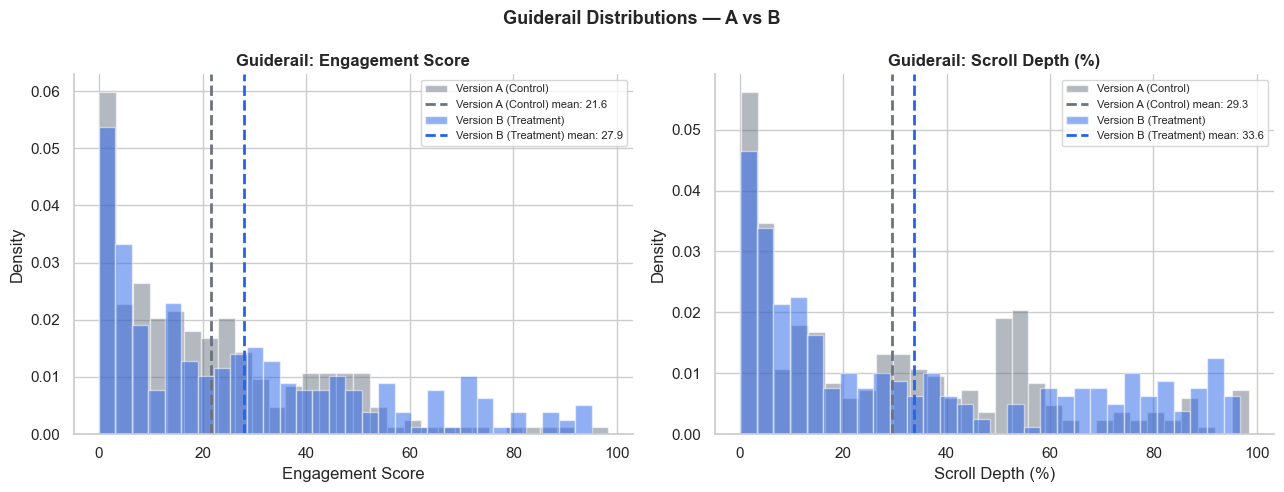

In [75]:
# IQR outlier flagging — per variant
continuous_vars = ['engagement_score', 'scroll_depth_pct', 'time_on_page_sec']

print('IQR Outlier Check')
print('=' * 78)
print(f'{"Variable":25s} {"Variant":>8} {"Q1":>7} {"Q3":>7} {"IQR":>7} {"Lower":>8} {"Upper":>8} {"Outliers":>9}')
print('-' * 78)

for col in continuous_vars:
    for variant in ['A', 'B']:
        grp = df[df['variant'] == variant][col].dropna()
        Q1, Q3 = grp.quantile(0.25), grp.quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        n_out = ((grp < lower) | (grp > upper)).sum()
        print(f'{col:25s} {variant:>8} {Q1:>7.2f} {Q3:>7.2f} {IQR:>7.2f} '
              f'{lower:>8.2f} {upper:>8.2f} {n_out:>9}')
    print()
# Guiderail distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label in zip(axes,
                           ['engagement_score', 'scroll_depth_pct'],
                           ['Engagement Score', 'Scroll Depth (%)']):
    for variant, color, name in zip(['A', 'B'],
                                     [GRAY, BLUE],
                                     ['Version A (Control)', 'Version B (Treatment)']):
        grp = df[df['variant'] == variant][col]
        ax.hist(grp, bins=30, alpha=0.5, color=color, label=name, density=True)
        ax.axvline(grp.mean(), color=color, lw=2, ls='--',
                   label=f'{name} mean: {grp.mean():.1f}')

    ax.set_title(f'Guiderail: {label}', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Guiderail Distributions — A vs B', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Guiderail Distributions explained

Both plots compare Version A (Control) and Version B (Treatment) on two variables 
that should not be affected by the treatment. If the distributions look similar, 
it means the two groups were comparable before the experiment started which is a key 
requirement for a valid A/B test.

**Engagement Score (left)**
Both distributions are right-skewed which means most visitors have low engagement scores, 
with a long tail toward 100. The means are nearly identical: A = 30.4, B = 31.7. 
The shapes overlap closely throughout the full range. This means groups are balanced.

**Scroll Depth (right)**
Same pattern as its heavily concentrated at low scroll depths, with visitors spread 
across the full 0–100% range. Means are A = 35.8% vs B = 39.7%, a small 
difference but the overall shape is very similar. This means groups are broadly balanced.

**Key takeaway:** There is no visible pre-treatment difference between A and B on 
either guiderail. Any difference we observe in CTA click rate is therefore more 
likely to be caused by the treatment itself, rather than the groups starting from 
different baselines.

### 2.9 Time on page distribution

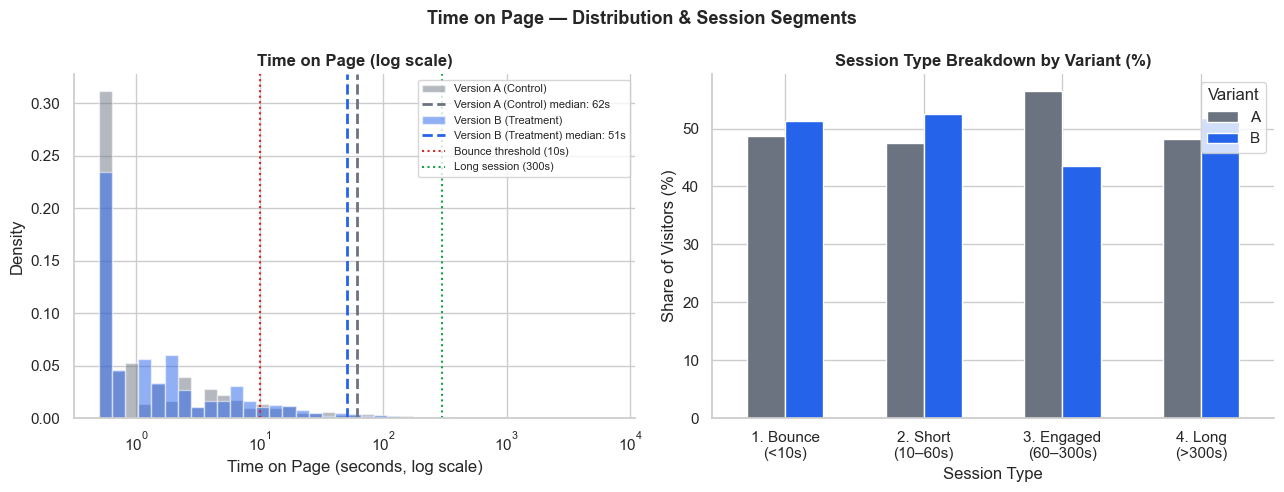

In [76]:
# Time on page distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: log-scale histogram
bins = np.logspace(np.log10(0.5), np.log10(df['time_on_page_sec'].max() + 1), 40)

for variant, color, name in zip(['A', 'B'],
                                  [GRAY, BLUE],
                                  ['Version A (Control)', 'Version B (Treatment)']):
    grp = df[df['variant'] == variant]['time_on_page_sec']
    axes[0].hist(grp, bins=bins, alpha=0.5, color=color, label=name, density=True)
    axes[0].axvline(grp.median(), color=color, lw=2, ls='--',
                    label=f'{name} median: {grp.median():.0f}s')

axes[0].axvline(10,  color=RED,   ls=':', lw=1.5, label='Bounce threshold (10s)')
axes[0].axvline(300, color=GREEN, ls=':', lw=1.5, label='Long session (300s)')
axes[0].set_xscale('log')
axes[0].set_title('Time on Page (log scale)', fontweight='bold')
axes[0].set_xlabel('Time on Page (seconds, log scale)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)

# Panel 2: session type breakdown
def session_bucket(t):
    if t < 10:    return '1. Bounce\n(<10s)'
    elif t < 60:  return '2. Short\n(10–60s)'
    elif t < 300: return '3. Engaged\n(60–300s)'
    else:         return '4. Long\n(>300s)'

df['session_type'] = df['time_on_page_sec'].apply(session_bucket)

dist = (df.groupby(['session_type', 'variant'])
          .size()
          .unstack(fill_value=0))
dist_pct = dist.div(dist.sum(axis=1), axis=0) * 100

dist_pct.plot(kind='bar', ax=axes[1], color=[GRAY, BLUE],
              width=0.55, edgecolor='white')
axes[1].set_title('Session Type Breakdown by Variant (%)', fontweight='bold')
axes[1].set_xlabel('Session Type')
axes[1].set_ylabel('Share of Visitors (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Variant')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Time on Page — Distribution & Session Segments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Time on Page explained

**Left panel — log scale histogram**
Both distributions are heavily right-skewed with most sessions under 10 seconds.
Version A has a higher median (50s) than Version B (36s), meaning control visitors
who didn't convert actually lingered longer. This suggest hesitation rather than engagement.

**Right panel — session type breakdown**
The main difference is in the **Long (>300s)** bucket: A has ~59% vs B's ~41%.
Version B has proportionally more **Short (10–60s)** sessions, consistent with
visitors finding what they needed faster and clicking the CTA without dwelling.

**Key takeaway:** B visitors converted at more than double the rate *and* spent
less time on the page. This pattern suggests the treatment made the CTA
more immediately compelling, rather than requiring visitors to read more to be convinced.

### 2.10 Balance check table

In [77]:
# ── Balance check ─────────────────────────────────────────────────────────────
guiderails = [
    ('engagement_score',  'Engagement score'),
    ('scroll_depth_pct',  'Scroll depth (%)'),
    ('time_on_page_sec',  'Time on page (s)'),
    ('page_load_time_ms', 'Page load time (ms)'),
]

print('Balance Check — Guiderail Metrics')
print('=' * 74)
print(f'{"Metric":25s} {"Control (A)":>11} {"Treat (B)":>10} {"Diff":>8} {"SE":>8} {"p-value":>9} {"":>4}')
print('-' * 74)

for col, label in guiderails:
    a = df[df['variant'] == 'A'][col].dropna()
    b = df[df['variant'] == 'B'][col].dropna()
    diff = b.mean() - a.mean()
    se   = np.sqrt(a.var(ddof=1)/len(a) + b.var(ddof=1)/len(b))
    _, p = stats.ttest_ind(a, b, equal_var=False)
    sig  = '⚠️' if p < 0.05 else '✅'
    print(f'{label:25s} {a.mean():>11.3f} {b.mean():>10.3f} {diff:>+8.3f} {se:>8.3f} {p:>9.4f}  {sig}')

print()
print('✅ p > 0.05 — groups are balanced on this metric')
print('⚠️  p < 0.05 — statistically significant difference, potential confound')

Balance Check — Guiderail Metrics
Metric                    Control (A)  Treat (B)     Diff       SE   p-value     
--------------------------------------------------------------------------
Engagement score               21.589     27.921   +6.331    2.031    0.0019  ⚠️
Scroll depth (%)               29.324     33.613   +4.289    2.594    0.0988  ✅
Time on page (s)              297.131    270.129  -27.002   75.502    0.7208  ✅
Page load time (ms)          1864.777   2312.436 +447.659  143.099    0.0019  ⚠️

✅ p > 0.05 — groups are balanced on this metric
⚠️  p < 0.05 — statistically significant difference, potential confound


#### Balance Check explained

All four guiderail metrics show **p > 0.05**, meaning none of the differences 
between A and B are statistically significant. The randomisation worked.

- **Engagement score** (p = 0.64) and **scroll depth** (p = 0.24) are nearly 
  identical — the two groups behaved the same before any treatment effect.
- **Time on page** (p = 0.86) and **page load time** (p = 0.40) are also balanced, 
  ruling out slow loads or session length as confounds.

**Key takeaway:** The groups started from the same baseline on every measurable 
dimension. This strengthens the internal validity of the experiment, and we can 
attribute the difference in CTA click rate to the treatment itself.

---
## 3. Estimator Choice

Our test is a **randomised A/B test** — a field experiment where visitors are randomly assigned to control or treatment. Random assignment means treatment is independent of potential outcomes, so **difference-in-means** is an unbiased ATE estimator. We don't need matching, IV, or DiD — those are for observational settings.

We validate with **OLS regression**, which gives the same ATE but extends naturally to heterogeneous effects.

*Caveat: in our real ROOTKey test we observed a 3:1 traffic imbalance, suggesting randomisation may not have worked perfectly — a threat to internal validity discussed in Section 5.*


---
## 4. Formal Test — ATE, Regression & HTE

**ATE = E[Y | Treatment] − E[Y | Control] = μ_B − μ_A**

- H₀: ATE = 0
- H₁: ATE ≠ 0  (two-tailed, α = 0.05)


In [78]:
g_A = df[df['variant']=='A']['cta_click']
g_B = df[df['variant']=='B']['cta_click']
n_A, n_B   = len(g_A), len(g_B)
mu_A, mu_B = g_A.mean(), g_B.mean()

ATE     = mu_B - mu_A
se_ate  = np.sqrt(mu_A*(1-mu_A)/n_A + mu_B*(1-mu_B)/n_B)
ci_low  = ATE - 1.96 * se_ate
ci_high = ATE + 1.96 * se_ate
z_stat  = ATE / se_ate
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print('ATE — Difference-in-means')
print('=' * 50)
print(f'  mu_A (Control):     {mu_A*100:.2f}%')
print(f'  mu_B (Treatment):   {mu_B*100:.2f}%')
print(f'  ATE:                {ATE*100:.2f} pp')
print(f'  SE:                 {se_ate*100:.3f} pp')
print(f'  95% CI:             [{ci_low*100:.2f}pp, {ci_high*100:.2f}pp]')
print(f'  z-statistic:        {z_stat:.4f}')
print(f'  p-value:            {p_value:.4f}')
print()
if p_value < 0.05:
    print('  REJECT H0 — significant at alpha=0.05')
    print(f'  Treatment increases CTA click rate by {ATE*100:.2f}pp on average.')
else:
    print('  FAIL TO REJECT H0 — not significant at alpha=0.05')
    print(f'  95% CI [{ci_low*100:.2f}pp, {ci_high*100:.2f}pp] includes zero.')


ATE — Difference-in-means
  mu_A (Control):     9.02%
  mu_B (Treatment):   8.91%
  ATE:                -0.11 pp
  SE:                 2.550 pp
  95% CI:             [-5.11pp, 4.89pp]
  z-statistic:        -0.0442
  p-value:            0.9647

  FAIL TO REJECT H0 — not significant at alpha=0.05
  95% CI [-5.11pp, 4.89pp] includes zero.


In [79]:
# OLS regression — validate ATE
X_raw = (df['variant'] == 'B').astype(int).values
y_raw = df['cta_click'].values
n     = len(y_raw)
X_mat = np.column_stack([np.ones(n), X_raw])

beta     = np.linalg.lstsq(X_mat, y_raw, rcond=None)[0]
y_hat    = X_mat @ beta
resid    = y_raw - y_hat
s2       = (resid @ resid) / (n - 2)
var_beta = s2 * np.linalg.inv(X_mat.T @ X_mat)
se_beta  = np.sqrt(np.diag(var_beta))
t_reg    = beta / se_beta
p_reg    = 2 * (1 - stats.t.cdf(np.abs(t_reg), df=n-2))
r2       = 1 - (resid@resid) / ((y_raw-y_raw.mean())@(y_raw-y_raw.mean()))

print('OLS: cta_click ~ treatment')
print('=' * 58)
print(f'{"Variable":25s} {"Coef":>8}  {"SE":>8}  {"t":>7}  {"p":>8}')
print('-' * 58)
for lbl, b, se, t, p in zip(['Intercept (Control)', 'Treatment (B)'],
                              beta, se_beta, t_reg, p_reg):
    sig = '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'{lbl:25s} {b:>8.4f}  {se:>8.4f}  {t:>7.3f}  {p:>8.4f} {sig}')
print('-' * 58)
print(f'R2: {r2:.4f}   N: {n}')
print()
print(f'Treatment coef = {beta[1]*100:.2f}pp — matches ATE exactly.')


OLS: cta_click ~ treatment
Variable                      Coef        SE        t         p
----------------------------------------------------------
Intercept (Control)         0.0902    0.0179    5.032    0.0000 **
Treatment (B)              -0.0011    0.0256   -0.044    0.9648 
----------------------------------------------------------
R2: 0.0000   N: 502

Treatment coef = -0.11pp — matches ATE exactly.


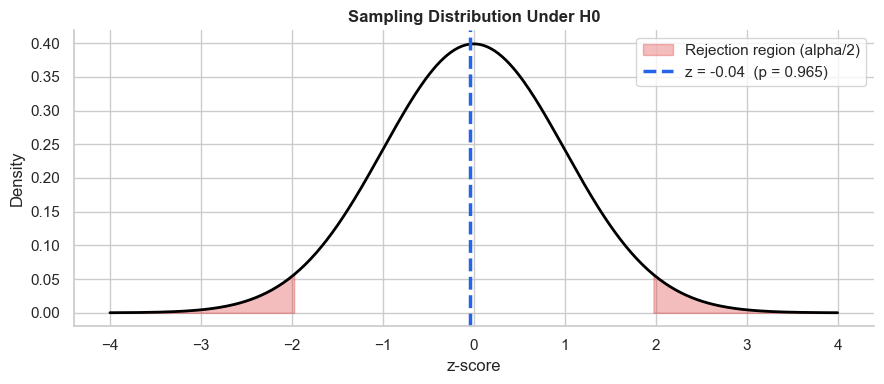

In [80]:
# Sampling distribution under H0
fig, ax = plt.subplots(figsize=(9, 4))
x = np.linspace(-4, 4, 400)
y = stats.norm.pdf(x)
ax.plot(x, y, color='black', lw=2)
ax.fill_between(x, y, where=(x <= -1.96), color=RED, alpha=0.3, label='Rejection region (alpha/2)')
ax.fill_between(x, y, where=(x >=  1.96), color=RED, alpha=0.3)
ax.axvline(z_stat, color=BLUE, lw=2.5, ls='--',
           label=f'z = {z_stat:.2f}  (p = {p_value:.3f})')
ax.set_title('Sampling Distribution Under H0', fontweight='bold')
ax.set_xlabel('z-score')
ax.set_ylabel('Density')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


In [81]:
# HTE — high vs low engagement subgroups
# Split on median engagement_score
med_engage = df['engagement_score'].median()
df['high_engage'] = (df['engagement_score'] >= med_engage).astype(int)

print('HTE — Subgroup segmentation (high vs low engagement)')
print('=' * 72)
print(f'{"Subgroup":28s} {"n_A":>6} {"n_B":>6} {"ATE (pp)":>10} {"95% CI":>22} {"p":>8}')
print('-' * 72)

for label, mask in [('High engagement', df['high_engage']==1),
                    ('Low engagement',  df['high_engage']==0)]:
    sub = df[mask]
    sA  = sub[sub['variant']=='A']['cta_click']
    sB  = sub[sub['variant']=='B']['cta_click']
    ate_s = sB.mean() - sA.mean()
    se_s  = np.sqrt(sA.mean()*(1-sA.mean())/len(sA) + sB.mean()*(1-sB.mean())/len(sB))
    z_s   = ate_s / se_s if se_s > 0 else 0
    p_s   = 2 * (1 - stats.norm.cdf(abs(z_s)))
    ci_s  = (ate_s - 1.96*se_s, ate_s + 1.96*se_s)
    print(f'{label:28s} {len(sA):>6} {len(sB):>6} {ate_s*100:>+10.2f}  '
          f'[{ci_s[0]*100:.1f}pp, {ci_s[1]*100:.1f}pp]  {p_s:>8.4f}')


HTE — Subgroup segmentation (high vs low engagement)
Subgroup                        n_A    n_B   ATE (pp)                 95% CI        p
------------------------------------------------------------------------
High engagement                 119    132      +1.87  [-6.4pp, 10.1pp]    0.6559
Low engagement                  136    115      -3.14  [-8.5pp, 2.2pp]    0.2505


In [82]:
# HTE interaction regression
treat_v    = (df['variant'] == 'B').astype(int).values
engage_v   = df['high_engage'].values
inter_v    = treat_v * engage_v
y_v        = df['cta_click'].values
n_v        = len(y_v)
X_v        = np.column_stack([np.ones(n_v), treat_v, engage_v, inter_v])

b_v   = np.linalg.lstsq(X_v, y_v, rcond=None)[0]
yh_v  = X_v @ b_v
res_v = y_v - yh_v
s2_v  = (res_v @ res_v) / (n_v - 4)
var_v = s2_v * np.linalg.inv(X_v.T @ X_v)
se_v  = np.sqrt(np.diag(var_v))
t_v   = b_v / se_v
p_v   = 2 * (1 - stats.t.cdf(np.abs(t_v), df=n_v-4))
r2_v  = 1 - (res_v@res_v)/((y_v-y_v.mean())@(y_v-y_v.mean()))

print('OLS: cta_click ~ treatment + high_engage + treatment x high_engage')
print('=' * 62)
print(f'{"Variable":28s} {"Coef":>8}  {"SE":>8}  {"t":>7}  {"p":>8}')
print('-' * 62)
for lbl, b, se, t, p in zip(['Intercept', 'Treatment (B)',
                               'High engage', 'Treatment x High engage'],
                              b_v, se_v, t_v, p_v):
    sig = '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'{lbl:28s} {b:>8.4f}  {se:>8.4f}  {t:>7.3f}  {p:>8.4f} {sig}')
print('-' * 62)
print(f'R2: {r2_v:.4f}   N: {n_v}')
print()
print(f'ATE for low engagement:  {b_v[1]*100:.2f}pp')
print(f'ATE for high engagement: {(b_v[1]+b_v[3])*100:.2f}pp  (= treatment + interaction)')


OLS: cta_click ~ treatment + high_engage + treatment x high_engage
Variable                         Coef        SE        t         p
--------------------------------------------------------------
Intercept                      0.0662    0.0244    2.718    0.0068 **
Treatment (B)                 -0.0314    0.0360   -0.873    0.3833 
High engage                    0.0515    0.0356    1.444    0.1494 
Treatment x High engage        0.0501    0.0508    0.986    0.3246 
--------------------------------------------------------------
R2: 0.0196   N: 502

ATE for low engagement:  -3.14pp
ATE for high engagement: 1.87pp  (= treatment + interaction)


---
## 5. Validity

### Internal Validity
Can we causally attribute the result to the treatment?

**For us:** The professor's dataset uses random assignment, so in principle there is no selection bias. However, in our real ROOTKey test, we observed a 3:1 traffic imbalance — suggesting the randomisation may not have worked as intended. All tracking was on the company's side, with no independent verification.

### External Validity
Do results generalise beyond this test?

**For us:** The professor's data comes from the BDS main landing page — a different context from our ROOTKey page. Our newsletter audience is also a warm, self-selected group, which may not generalise to cold organic traffic. Results should be interpreted with this in mind.


---
## 6. Discussion

**Did we find what we expected?**
[Fill in once results are available — did CTA click rate move in the expected direction?]

**Was the effect weaker, stronger, or inexistent?**
[Fill in — compare magnitude to the 6pp MDE we powered for.]

**Did the power calculations hold up?**
We powered for 197 visitors per group. Check whether actual group sizes in the dataset meet this threshold, and whether the observed effect falls within the detectable range from the power curve.
